# Kwant — Theory and Practice · Chapter 7
## Solvers, performance, pitfalls — and the exercises for Part I

*Part I · Sections 15–16 · Figure 34* &nbsp;·&nbsp; [← Chapter 6](06_Magnetic_Fields.ipynb) · [Contents](00_Contents.ipynb) · [Chapter 8 →](08_Topology_in_One_Dimension.ipynb)

### In this chapter

- [15. Solvers, performance and scaling](#15.-Solvers,-performance-and-scaling)
    - [What actually costs time](#What-actually-costs-time)
    - [Choosing a solver](#Choosing-a-solver)
    - [Practical rules](#Practical-rules)
- [16. Pitfalls — the things that actually go wrong](#16.-Pitfalls-—-the-things-that-actually-go-wrong)
    - [Correctness checks worth running](#Correctness-checks-worth-running)
- [Exercises for Part I](#Exercises-for-Part-I)

**Exercises** E1.1–E1.11 are posed at the end of this chapter; the worked, asserted solutions are in [`S1_Solutions_Part_I.ipynb`](S1_Solutions_Part_I.ipynb).

Run the **Setup** cell first: it imports Kwant, reports the sparse solver, mutes three library warnings and defines `show_fig`, whose figure counter continues the course-wide numbering. Each chapter is self-contained given its Setup cell (a *carried over* cell, where present, rebuilds an object defined in an earlier chapter). Installation, the `kwant` kernel and the conventions are in [`00_Contents.ipynb`](00_Contents.ipynb).

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.


In [1]:
# --- Setup: run this cell first ----------------------------------------------
# Imports, the sparse-solver report, three muted library warnings, and the
# figure helper.  Every chapter of the course starts with this cell.
import kwant
import numpy as np
import scipy
import tinyarray as ta                   # noqa: F401  (used by later cells)
import matplotlib
from matplotlib import pyplot

print("kwant", kwant.__version__, "| numpy", np.__version__,
      "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)

# Which sparse solver is active? MUMPS is much faster than SciPy's SuperLU.
import kwant.solvers.default
print("default solver:", kwant.solvers.default.__name__)
try:
    import kwant.solvers.mumps          # noqa: F401
    print("MUMPS available: yes")
except ImportError:
    print("MUMPS available: no  (falling back to scipy sparse -> slower)")

matplotlib.rcParams['figure.figsize'] = (7, 5)

# Mute three library warnings that are not ours to fix and would otherwise be
# printed under some figures.  Done by wrapping warnings.showwarning rather than
# with warnings.filterwarnings(), because kwant.plotter calls
# warnings.resetwarnings() on every 3D plot, which silently deletes all user
# filters (reported upstream).  Only these three messages are muted:
#  * kwant 1.5.0's 3D plotter calls a matplotlib function deprecated in 3.10
#    (fixed on Kwant's main branch, unreleased);
#  * mpmath (via sympy) uses a deprecated bitcount helper;
#  * kwant.plotter.map notes that a few density values exceed the colour range,
#    which is expected for the delta-like densities in sections 6 and 12.
import warnings
_MUTED = ('proj_transform_clip', 'bitcount function is deprecated', 'overflowing upper limit')
_showwarning = warnings.showwarning

def _quiet_showwarning(message, category, filename, lineno, file=None, line=None):
    if not any(k in str(message) for k in _MUTED):
        _showwarning(message, category, filename, lineno, file, line)

warnings.showwarning = _quiet_showwarning

# --- Figure helper ------------------------------------------------------------
# Every figure ends with show_fig("..."), which stamps an auto-numbered italic
# caption under the figure and then shows it.  Figures are numbered
# continuously across the chapters of the course: this chapter's figures are
# figure 34 only, so the counter starts at 33.  (Re-running a single cell out of
# order advances it -- harmless, but numbers shift.)
_FIG_NO = [33]

def show_fig(caption=None):
    if caption:
        _FIG_NO[0] += 1
        fig = pyplot.gcf()
        fig.text(0.5, -0.02, f"Figure {_FIG_NO[0]}: {caption}",
                 ha='center', va='top', fontsize=9, style='italic',
                 wrap=True, transform=fig.transFigure)
    pyplot.show()


kwant 1.5.0 | numpy 2.5.1 | scipy 1.18.0 | matplotlib 3.10.7
default solver: kwant.solvers.default
MUMPS available: yes


In [2]:
# --- Carried over from section 3 -----------------------------------
# the two-terminal quantum wire `fsyst` of § 3 (used by the parallel sweep).
# The code is the definition of section 3, verbatim.
import kwant
import numpy as np
from matplotlib import pyplot
a, t, W, L = 1, 1.0, 10, 30
lat = kwant.lattice.square(a, norbs=1)
def make_wire(W=10, L=30, t=1.0):
    syst = kwant.Builder()

    # Scattering region: on-site 4t, nearest-neighbour hopping -t
    syst[(lat(x, y) for x in range(L) for y in range(W))] = 4 * t
    syst[lat.neighbors()] = -t

    # A lead: one unit cell + translational symmetry pointing left, away from syst
    lead = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)))
    lead[(lat(0, j) for j in range(W))] = 4 * t
    lead[lat.neighbors()] = -t

    syst.attach_lead(lead)               # becomes lead 0 (left)
    syst.attach_lead(lead.reversed())    # becomes lead 1 (right)
    return syst

fsyst = make_wire().finalized()


---
## 15. Solvers, performance and scaling

### What actually costs time

For a scattering problem Kwant assembles a sparse linear system of dimension
$\sim N_{\text{orb}}$ (scattering region) $+$ lead modes, and solves it by **sparse LU
factorisation**. Cost is dominated by fill-in during factorisation, which depends on the
*shape* of the system, not just its size:

- **Quasi-1D** (long, thin): cost $\sim O(L W^3)$ — cheap. Long wires are fine.
- **2D square** ($N = L^2$ sites): $\sim O(N^{3/2})$.
- **3D**: $\sim O(N^2)$ — this is where you hit the wall.

### Choosing a solver

| Module | Backend | Notes |
|---|---|---|
| `kwant.solvers.mumps` | MUMPS | **Much faster**, multithreaded, memory-tunable. Use it. |
| `kwant.solvers.sparse` | SciPy SuperLU | Always available, the fallback. |
| `kwant.solvers.default` | whichever is best available | what `kwant.smatrix` uses |

```python
import kwant.solvers.mumps as mumps
mumps.options(nrhs=10, ordering='metis', sparse_rhs=True)
```

- `nrhs` — solve for several right-hand sides at once. Big win when a lead has many modes.
- `ordering` — `'metis'` or `'scotch'` usually beat the default on large 2-D/3-D systems.
- `sparse_rhs` — keeps the right-hand side sparse; helps memory on wide leads.

### Practical rules

1. **Build once, solve many.** Construction and finalisation are expensive; parameterise
   with `params` and re-solve. Never rebuild inside an energy loop.
2. **`smatrix` vs `wave_function`.** If you only need conductance, `smatrix` is cheaper —
   `wave_function` reconstructs the full state in the scattering region.
3. **Use `tinyarray`** for small fixed matrices, not NumPy. Order-of-magnitude difference.
4. **Shift-invert for closed systems** (`sigma=0` in `eigsh`), never plain `which='SM'`.
5. **KPM instead of diagonalisation** when you want spectra of very large systems (§ 12).
6. Kwant releases the GIL in its heavy routines, and parameter sweeps are embarrassingly
   parallel — `multiprocessing` over energies/fields is the easy speedup.
7. `hamiltonian_submatrix(sparse=True)` — the dense default will exhaust memory on any
   serious system.

using MUMPS, ordering = 'auto'


W= 10  sites=    400  solve= 0.068 s


W= 20  sites=   1600  solve= 0.186 s


W= 40  sites=   6400  solve= 0.517 s


W= 60  sites=  14400  solve= 1.890 s


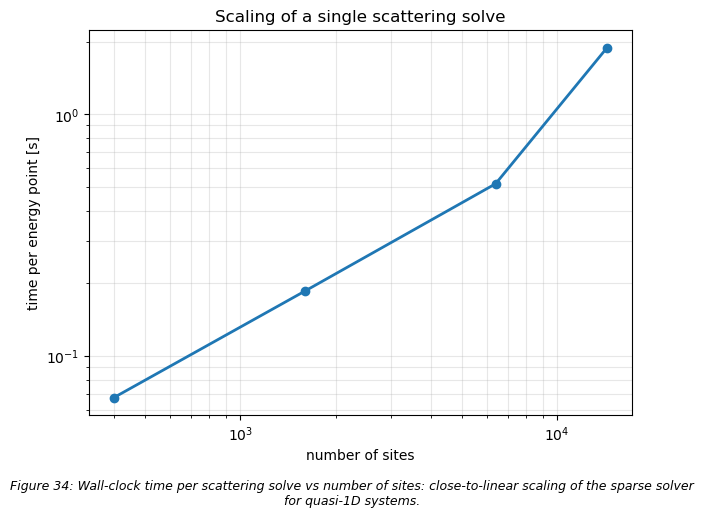

In [3]:
# --- Solver selection and a scaling measurement ------------------------------
import time, numpy as np, kwant
from matplotlib import pyplot

try:
    import kwant.solvers.mumps as mumps
    # The nested-dissection orderings ('metis', 'scotch') are the good ones for
    # 2D lattices, but not every MUMPS build ships them.  Requesting an absent
    # ordering is NOT an error -- MUMPS silently falls back -- so let Kwant pick
    # the best one actually compiled in, and print what was really chosen.
    mumps.options(nrhs=6, ordering='kwant_decides')
    print(f"using MUMPS, ordering = {mumps.default_solver.ordering!r}")
except ImportError:
    print("MUMPS unavailable; using scipy sparse")

lat = kwant.lattice.square(norbs=1)

def timed_wire(L, W, t=1.0):
    syst = kwant.Builder()
    syst[(lat(x, y) for x in range(L) for y in range(W))] = 4 * t
    syst[lat.neighbors()] = -t
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
    lead[(lat(0, j) for j in range(W))] = 4 * t
    lead[lat.neighbors()] = -t
    syst.attach_lead(lead); syst.attach_lead(lead.reversed())
    f = syst.finalized()

    t0 = time.time()
    kwant.smatrix(f, 0.5).transmission(1, 0)
    return len(f.sites), time.time() - t0

timed_wire(L=4 * 10, W=10)  # warm-up: first MUMPS call pays one-off symbolic-
                            # factorisation / import overhead that has nothing
                            # to do with system size and would otherwise pollute
                            # the smallest data point below
sizes, times = [], []
for W in (10, 20, 40, 60):
    n, dt = timed_wire(L=4 * W, W=W)
    sizes.append(n); times.append(dt)
    print(f"W={W:3d}  sites={n:7d}  solve={dt:6.3f} s")

pyplot.loglog(sizes, times, 'o-', lw=2)
pyplot.xlabel("number of sites"); pyplot.ylabel("time per energy point [s]")
pyplot.title("Scaling of a single scattering solve")
pyplot.grid(alpha=.3, which='both'); show_fig(r'Wall-clock time per scattering solve vs number of sites: close-to-linear scaling of the sparse solver for quasi-1D systems.')

In [4]:
# --- Parallel parameter sweep -------------------------------------------------
# Energy points are independent, so an energy sweep is embarrassingly parallel.
# But HOW you parallelise it matters, and the obvious way crashes the kernel:
#
#   !!! NEVER call kwant.smatrix from several threads at once. !!!
#
# `kwant.smatrix` dispatches to MUMPS whenever MUMPS is installed, and MUMPS is
# not re-entrant: concurrent solves corrupt its internal state and abort the
# *process*.  In a notebook that surfaces as
#     "The Kernel crashed while executing code in the current cell..."
# It is a segfault, not a Python exception, so try/except cannot catch it, and
# giving each thread its own Solver() instance does not help either -- the
# shared state lives inside the MUMPS library, not in Kwant.
#
# Two safe options:
#   (a) threads + the SciPy/SuperLU solver, which IS re-entrant  -> shown below
#   (b) one process per worker, each with its own MUMPS          -> note at end

import time
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import kwant
import kwant.solvers.sparse as scipy_solver   # SuperLU: safe to call from threads

energies = np.linspace(0.01, 1.0, 64)


def transmission(e):
    # NOTE: scipy_solver.smatrix, *not* kwant.smatrix -- see the warning above.
    return scipy_solver.smatrix(fsyst, e).transmission(1, 0)


t0 = time.perf_counter()
data_serial = np.array([transmission(e) for e in energies])
t_serial = time.perf_counter() - t0

t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=4) as pool:
    data_par = np.array(list(pool.map(transmission, energies)))
t_par = time.perf_counter() - t0

assert np.allclose(data_par, data_serial), "parallel result disagrees with serial!"

print(f"serial     {t_serial:6.2f} s")
print(f"4 threads  {t_par:6.2f} s   ->  speedup x{t_serial / t_par:.2f}")
print("T at the last five energies:", np.round(data_par[-5:], 6))   # the first few lie below the lowest subband

# Do not be surprised if the speedup is close to 1x -- or even below it.
# SuperLU holds the GIL for much of the factorisation, and NumPy/SciPy are
# already linked against a multithreaded BLAS that is using every core, so
# Python-level threads mostly add contention.  Measure before you believe.
#
# For a genuine speedup on a long sweep, use PROCESSES.  On Windows the worker
# must be importable, so put it in a module (e.g. sweep_worker.py) rather than
# in a notebook cell, and drive it from a script:
#
#     # sweep_worker.py
#     import kwant
#     _F = None
#     def transmission(e):
#         global _F
#         if _F is None:
#             _F = make_wire()          # each process builds its own system
#         return kwant.smatrix(_F, e).transmission(1, 0)   # MUMPS is fine here:
#                                                          # one solver per process
#     # driver.py
#     from concurrent.futures import ProcessPoolExecutor
#     from sweep_worker import transmission
#     if __name__ == "__main__":                            # required on Windows
#         with ProcessPoolExecutor(max_workers=4) as pool:
#             data = list(pool.map(transmission, energies, chunksize=4))


serial       5.16 s
4 threads    3.26 s   ->  speedup x1.58
T at the last five energies: [3. 3. 3. 3. 3.]


---
## 16. Pitfalls — the things that actually go wrong

**`norbs` not set.** `kwant.operator` refuses to work, symmetry checks are skipped, and you
get confusing errors much later. Set it on every lattice, always.

**Tuple vs generator when adding sites.**
`syst[(lat(0,0), lat(1,0))] = x` adds a *hopping*, not two sites — because `syst[a, b]` is
`syst[(a, b)]`. Add several sites with a generator or a list.

**Lead symmetry vector points the wrong way.** It must point *away from* the scattering
region, into the lead. `(-a, 0)` = left lead. Use `lead.reversed()` for the other side.

**Dangling sites on non-square lattices.** Cutting a honeycomb or kagome lattice to a shape
leaves atoms with one neighbour, which produce spurious near-zero-energy states.
`syst.eradicate_dangling()`.

**Hermiticity is automatic — and overwritable.** Kwant adds the conjugate hopping for you,
so setting both directions with inconsistent values silently keeps the last one written.

**Closed-system eigenvalues converge slowly** unless you use shift-invert
(`eigsh(..., sigma=0)`).

**`conservation_law` declared where it does not hold.** In a superconducting lead $\Delta$
mixes electrons and holes; declaring `-tau_z` there gives wrong mode labelling. Only declare
symmetries that are actually present.

**Magnetic field too strong for the lattice.** Flux per plaquette must satisfy
$Ba^2 \ll \Phi_0$, otherwise you are computing Hofstadter physics, not continuum Landau
levels. Also, a naive gauge can break lead periodicity — use
`kwant.physics.magnetic_gauge` (Kwant >=1.4; **broken on Kwant 1.5.0 with numpy >=2.5**, see the
manual, §2.3 -- this course pins `numpy<2.5` and never calls this function itself).

**Discretisation too coarse.** The tight-binding model matches the continuum only for
wavelengths $\gg a$. Always check convergence in $a$, and compare against
`kwant.continuum.lambdify` near $k=0$.

**`kwant.smatrix` is not thread-safe when MUMPS is installed.** Concurrent calls from a
thread pool corrupt MUMPS's internal state and segfault the interpreter -- in a notebook
that is the dreaded "kernel crashed" with no traceback. One solver instance per thread does
*not* help; the shared state is inside the MUMPS library. Threads: use
`kwant.solvers.sparse` (SuperLU, re-entrant). MUMPS in parallel: one process per worker.
See section 15 and `test_thread_safety.py`.

**Rebuilding inside a loop.** Construction dominates runtime. Build once, sweep with
`params`.

**`hamiltonian_submatrix()` dense by default.** Pass `sparse=True` for anything non-trivial.

**Plotting callbacks take different arguments** on a `Builder` (`Site` objects) than on a
finalised system (integer indices).

### Correctness checks worth running

```python
S = kwant.smatrix(fsyst, E).data
assert np.allclose(S.conj().T @ S, np.eye(len(S)))      # unitarity == current conservation
assert np.isclose(T + R, N)                             # sum rule
```

Unitarity failing almost always means the leads are ill-defined — a lead that is not
translationally invariant, or a mode count that changes discontinuously because you sit
exactly at a band edge. Move off the band edge and re-check.

---
## Exercises for Part I

Worked solutions for every exercise are in the companion notebook
**`S1_Solutions_Part_I.ipynb`** (same folder).  Difficulty: ◦ = direct,
• = requires some thought, ★ = mini-project.  Every exercise states its
origin.

**E1.1** ◦ *(from the Kwant tutorial, "quantum wire" chapter)* — Thread a
perpendicular magnetic field through the clean wire of §3 with Peierls
phases and compute $G(B)$ at fixed energy.  Explain the step-downs you see
in terms of magnetic depopulation of subbands.

**E1.2** ◦ *(from the Kwant tutorial, spin chapter)* — Add a Zeeman term
$E_Z\sigma_z$ to the wire and recompute the staircase.  Why do the steps
split into half-steps of $e^2/2h$... and at which energies?

**E1.3** • *(original, this notebook)* — The Landauer formula at finite
temperature reads $G = (e^2/h)\int dE\,T(E)\,(-\partial f/\partial E)$.
Take the $T(E)$ of the quantum-well resonance of §5 and plot $G(T_{\rm
temp})$; show the resonance washes out when $k_BT \sim \Gamma$.

**E1.4** ◦ *(adapted from the Kwant tutorial well example)* — Sweep the well
*width* instead of its depth and interpret the spacing of the resonances.

**E1.5** • *(original)* — Universal conductance fluctuations: give the
stadium dot two point-contact leads, compute $G$ over a dense energy window,
and compare $\sqrt{\mathrm{var}\,G}$ with the universal value
$\sim e^2/h$ [Beenakker, RMP 69, 731 (1997)].

**E1.6** • *(original)* — In the graphene p-n junction of §8, sweep the
junction smoothness $w$ and show that transmission at the Dirac point drops
as the junction gets smoother (only near-normal incidence survives —
Cheianov & Fal'ko, PRB 74, 041403 (2006)).

**E1.7** • *(after Blonder-Tinkham-Klapwijk, PRB 25, 4515 (1982))* — For the
N-S junction of §9, map the barrier strength to the BTK parameter $Z$ by
fitting the sub-gap conductance suppression $G(0)/G_N = 1/(1+Z^2)^{...}$ —
or simply plot $G(E=0)$ vs barrier and compare with BTK's
$(1+2Z^2)^{-2}$-type suppression.

**E1.8** ★ *(original)* — Andreev bound states and the Josephson effect:
build an S-N-S junction with pairing phases $0$ and $\varphi$ on the two
sides (no leads; closed system), diagonalise, and plot the sub-gap spectrum
vs $\varphi$.  Verify the ABS dispersion $E \approx \pm\Delta\sqrt{1-\tau
\sin^2(\varphi/2)}$ and sketch the current-phase relation $I \propto
dE/d\varphi$.

**E1.9** ◦ *(from the Kwant KPM documentation)* — Recompute the graphene DOS
of §12 with 10× fewer moments, with and without the Jackson kernel, and
observe Gibbs oscillations vs resolution loss.

**E1.10** • *(after Osadchy & Avron, J. Math. Phys. 42, 5665 (2001))* —
Using the Diophantine solution from the coloured-butterfly cell of §14,
render the classic *flat* coloured butterfly: the $(\phi, E)$ plane with
every gap painted by its Chern number.

**E1.11** ◦ *(pencil, original)* — Show that the FHS plaquette flux
$F = \arg(U_1U_2U_3U_4)$ is invariant under $u_{\mathbf k} \to
e^{i\chi(\mathbf k)}u_{\mathbf k}$, and explain why summing it over the
torus must give an integer multiple of $2\pi$.